# Notebook 02 -- Data Generation (M2)

This notebook is the M2 deliverable from
[`../../cstr_sbi_execution_plan.md`](../../cstr_sbi_execution_plan.md):

* a JAX-vectorised stochastic simulator with process noise (Euler-Maruyama)
  and a Gaussian sensor layer with drift, and
* the labelled scenario datasets for the eight scenarios of
  [`../../cstr_sbi_research_spec.md`](../../cstr_sbi_research_spec.md) (Section 4)
  that downstream notebooks (M3 summary statistics, M4 SBI training, M5 MCMC
  baseline, M6 multi-sample study, M7 figures) consume.

**Outputs.** This notebook writes:

* [`../data/observations.npz`](../data/observations.npz) -- a packed array of
  replicate trajectories with their ground-truth scenario labels.
* [`../data/scenario_configs.csv`](../data/scenario_configs.csv) -- the
  scenario truth table in flat form.
* A handful of figures saved to [`../figures/`](../figures/).


## 1. Imports and the scenario table

In [1]:
import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cstr_sbi.physics import (
    NOMINAL_INLET, NOMINAL_INLET_CL, NOMINAL_CTRL, NOMINAL_Y0,
    QC0, TSP, K0_NOMINAL, UA_NOMINAL, V, V_C, Q,
)
from cstr_sbi.scenarios import SCENARIO_CONFIGS, list_configs
from cstr_sbi.simulator import (
    DEFAULT_PROCESS_SIGMA, DEFAULT_SENSOR_NOISE_PCT,
    DEFAULT_DT_INT, DEFAULT_DT_OUT,
    generate_replicates, warm_start_ic,
    _em_scan_open_loop,
)

print("JAX devices:", jax.devices())

scenario_rows = [
    {
        "id":          sc.id,
        "name":        sc.name,
        "mode":        sc.mode,
        "alpha":       sc.alpha,
        "beta":        sc.beta,
        "drift_T":     sc.drift_T,
        "description": sc.description,
    }
    for sc in list_configs()
]
scenarios_df = pd.DataFrame(scenario_rows).set_index("id")
scenarios_df

JAX devices: [CpuDevice(id=0)]


,name,mode,alpha,beta,drift_T,description
id,,,,,,
0,Sc0_open_healthy,open_loop,1.00,1.00,0.0,"Healthy reactor, open-loop (Qc fixed). Validat..."
1,Sc1_closed_healthy,closed_loop,1.00,1.00,0.0,"Healthy reactor, closed-loop with PI control. ..."
2,Sc2_closed_fouling,closed_loop,1.00,0.70,0.0,Jacket fouling (beta=0.7) -- primary fault sce...
3,Sc3_closed_decay,closed_loop,0.70,1.00,0.0,Catalyst decay (alpha=0.7).
4,Sc4_closed_combined,closed_loop,0.85,0.85,0.0,Combined moderate fouling and decay.
5,Sc5_closed_saturated,closed_loop,1.00,0.40,0.0,Severe fouling -- controller saturates at Qc_max.
6,Sc6_open_with_fault,open_loop,1.00,0.70,0.0,Open-loop simulator applied to a fault -- the ...
7,Sc7_closed_drift,closed_loop,1.00,0.85,2.0,Mild fouling plus +2 K sensor drift on T -- su...


## 2. Simulator settings

Process noise diffusion coefficients (``sigma * sqrt(dt)`` per Euler-Maruyama
step) and the Gaussian sensor layer parameters are pulled from
``cstr_sbi.simulator``. Both are tunable per-call.

The default sensor-noise level (0.5 percent of channel max) follows research
spec Section 3.5 verbatim and corresponds to roughly ``+/- 1.6 K`` on T --
realistic for an industrial-grade sensor and visible against a clean signal.


In [2]:
print(f"Process noise sigma [C, T, Tc, I] / sqrt(min) : {np.asarray(DEFAULT_PROCESS_SIGMA)}")
print(f"Sensor noise (fraction of channel max)         : {DEFAULT_SENSOR_NOISE_PCT}")
print(f"EM step dt                                     : {DEFAULT_DT_INT} min")
print(f"Output grid dt_out                             : {DEFAULT_DT_OUT} min")
print(f"Default observation window                     : 60 min")
print(f"  ->  {int(60 / DEFAULT_DT_OUT)} timestamps per replicate, 4 channels [C, T, Tc, Qc]")

Process noise sigma [C, T, Tc, I] / sqrt(min) : [0.0005 0.1    0.1    0.    ]
Sensor noise (fraction of channel max)         : 0.005
EM step dt                                     : 0.01 min
Output grid dt_out                             : 0.5 min
Default observation window                     : 60 min
  ->  120 timestamps per replicate, 4 channels [C, T, Tc, Qc]


## 3. Single-replicate visualisation -- Scenario 1 healthy

Before generating the full dataset we look at one replicate to confirm the
process noise + sensor noise pipeline produces a reasonable trajectory.
The dashed lines mark the deterministic steady state of the underlying
ODE; the solid lines are the noisy observed trajectory.


Sc1 warm-start IC (deterministic SS): [ 1.7909614e-02  3.1241403e+02  3.0013867e+02 -1.8222627e+02]


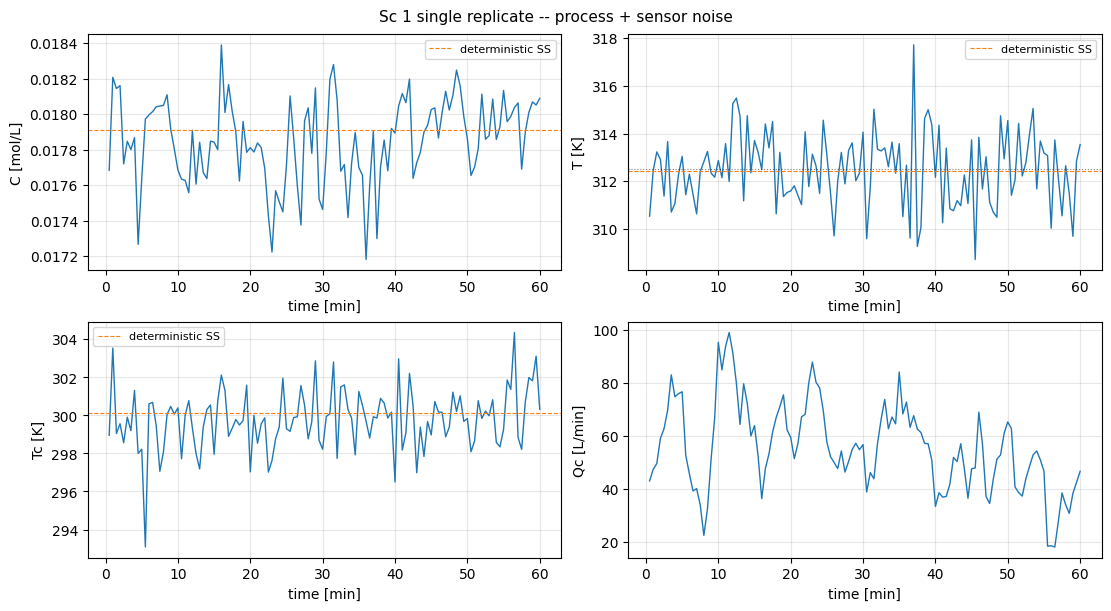


Per-replicate stats:
  C  mean = 0.01785   std = 0.00023
  T  mean = 312.4872    std = 1.5310
  Tc mean = 299.7753    std = 1.5878
  Qc mean = 55.653     std = 16.631


In [3]:
sc1 = SCENARIO_CONFIGS["Sc1_closed_healthy"]
y0_sc1 = warm_start_ic(sc1.params(), NOMINAL_INLET_CL, NOMINAL_CTRL)
print(f"Sc1 warm-start IC (deterministic SS): {np.asarray(y0_sc1)}")

t_out, obs_one = generate_replicates(
    sc1.params(), NOMINAL_INLET_CL, NOMINAL_CTRL, y0_sc1,
    n_replicates=1, master_key=jax.random.PRNGKey(0),
    t_window=60.0,
)
t = np.asarray(t_out)
o = np.asarray(obs_one[0])  # (n_t, 4)

fig, axes = plt.subplots(2, 2, figsize=(11, 6), constrained_layout=True)
labels = ["C [mol/L]", "T [K]", "Tc [K]", "Qc [L/min]"]
det_ss = [float(y0_sc1[0]), float(y0_sc1[1]), float(y0_sc1[2]), None]
for ax, lab, channel, det in zip(axes.ravel(), labels, range(4), det_ss):
    ax.plot(t, o[:, channel], lw=1.0)
    if det is not None:
        ax.axhline(det, color="C1", ls="--", lw=0.8, label="deterministic SS")
        ax.legend(loc="best", fontsize=8)
    if channel == 1:
        ax.axhline(TSP, color="k", ls=":", lw=0.8, alpha=0.5)
    ax.set_xlabel("time [min]"); ax.set_ylabel(lab); ax.grid(alpha=0.3)
fig.suptitle("Sc 1 single replicate -- process + sensor noise", fontsize=11)
plt.show()

print(f"\nPer-replicate stats:")
print(f"  C  mean = {o[:,0].mean():.5f}   std = {o[:,0].std():.5f}")
print(f"  T  mean = {o[:,1].mean():.4f}    std = {o[:,1].std():.4f}")
print(f"  Tc mean = {o[:,2].mean():.4f}    std = {o[:,2].std():.4f}")
print(f"  Qc mean = {o[:,3].mean():.3f}     std = {o[:,3].std():.3f}")

## 4. Generate replicates for all closed-loop scenarios

For Sc 1, 2, 3, 4, 5 and 7 we run ``N_REPLICATES = 50`` independent EM
trajectories using the closed-loop simulator with the scenario's
``(alpha, beta)`` truth and (for Sc 7) the prescribed sensor drift. Each
scenario uses its own deterministic warm-start IC.

Sc 0 and Sc 6 -- the open-loop scenarios -- use the open-loop simulator
with ``Qc`` held fixed at ``QC0`` and the fault encoded by scaling
``[UA, k0]`` directly: ``Qc`` is therefore *not* a useful fault signal in
those scenarios (it is constant by construction), and they exist mainly
to provide validation (Sc 0) and the failure-mode baseline (Sc 6).


In [4]:
N_REPLICATES = 50
T_WINDOW = 60.0

def generate_open_loop_replicates(
    UA_eff, k0_eff, n_replicates, master_key,
    t_window=T_WINDOW, dt=DEFAULT_DT_INT, dt_out=DEFAULT_DT_OUT,
    sigma_proc=DEFAULT_PROCESS_SIGMA, noise_pct=DEFAULT_SENSOR_NOISE_PCT,
    drift_T=0.0,
):
    """Open-loop variant -- 3-state, fixed Qc = QC0."""
    from cstr_sbi.simulator import _em_scan_open_loop, apply_sensor_layer

    params_ol = jnp.array([UA_eff, k0_eff])
    inlet_ol = jnp.asarray(NOMINAL_INLET).at[3].set(QC0)
    y0_ol = jnp.array([0.018, 312.15, 299.05])  # warm-start near healthy SS

    n_steps = int(round(t_window / dt))
    stride = int(round(dt_out / dt))
    keys = jax.random.split(master_key, 2 * n_replicates)
    proc_keys, sens_keys = keys[:n_replicates], keys[n_replicates:]

    @jax.vmap
    def one_rep(proc_k, sens_k):
        ys3 = _em_scan_open_loop(y0_ol, proc_k, params_ol, inlet_ol,
                                 dt, sigma_proc, n_steps, stride)
        qc_const = jnp.full((ys3.shape[0],), QC0)
        obs4 = jnp.stack([ys3[:, 0], ys3[:, 1], ys3[:, 2], qc_const], axis=1)
        return apply_sensor_layer(obs4, key=sens_k,
                                  noise_pct=noise_pct, drift_T=drift_T)
    obs = one_rep(proc_keys, sens_keys)
    t_out = jnp.arange(1, obs.shape[1] + 1) * dt_out
    return t_out, obs


master_key = jax.random.PRNGKey(2026)
all_results = {}

t0 = time.perf_counter()
for sc in list_configs():
    key = jax.random.fold_in(master_key, sc.id)
    if sc.mode == "closed_loop":
        params = sc.params()
        y0 = warm_start_ic(params, NOMINAL_INLET_CL, NOMINAL_CTRL)
        t_out, obs = generate_replicates(
            params, NOMINAL_INLET_CL, NOMINAL_CTRL, y0,
            n_replicates=N_REPLICATES, master_key=key,
            t_window=T_WINDOW, drift_T=sc.drift_T,
        )
    else:  # open_loop
        UA_eff = sc.beta * UA_NOMINAL
        k0_eff = sc.alpha * K0_NOMINAL
        t_out, obs = generate_open_loop_replicates(
            UA_eff, k0_eff, N_REPLICATES, key,
            drift_T=sc.drift_T,
        )
    obs_np = np.asarray(obs)
    all_results[sc.name] = {"t": np.asarray(t_out), "obs": obs_np, "config": sc}
    print(f"  {sc.name:28s}  {obs_np.shape}  "
          f"<C>={obs_np[:,:,0].mean():.4f}  <T>={obs_np[:,:,1].mean():.2f}  "
          f"<Qc>={obs_np[:,:,3].mean():.2f}")
print(f"\nTotal generation time: {time.perf_counter()-t0:.2f}s")

  Sc0_open_healthy              (50, 120, 4)  <C>=0.0184  <T>=312.15  <Qc>=80.01


  Sc1_closed_healthy            (50, 120, 4)  <C>=0.0179  <T>=312.47  <Qc>=52.70
  Sc2_closed_fouling            (50, 120, 4)  <C>=0.0171  <T>=312.97  <Qc>=214.03
  Sc3_closed_decay              (50, 120, 4)  <C>=0.0254  <T>=312.42  <Qc>=45.77


  Sc4_closed_combined           (50, 120, 4)  <C>=0.0207  <T>=312.56  <Qc>=91.56


  Sc5_closed_saturated          (50, 120, 4)  <C>=0.0153  <T>=314.17  <Qc>=382.96
  Sc6_open_with_fault           (50, 120, 4)  <C>=0.0171  <T>=312.95  <Qc>=80.01
  Sc7_closed_drift              (50, 120, 4)  <C>=0.0176  <T>=314.58  <Qc>=101.24

Total generation time: 1.94s


## 5. Visualise example replicates per scenario

Six replicates from each scenario, four channels each (12 panels per
scenario). The headline phenomenon -- the same `T` across scenarios
masks very different `Qc` -- is visible at a glance: jacket fouling
(Sc 2) keeps `Qc` near `Qc_max`, catalyst decay (Sc 3) keeps it low,
and Sc 5 sits at `Qc_max` saturation.


Saved: ../figures/02_scenarios_overview.png


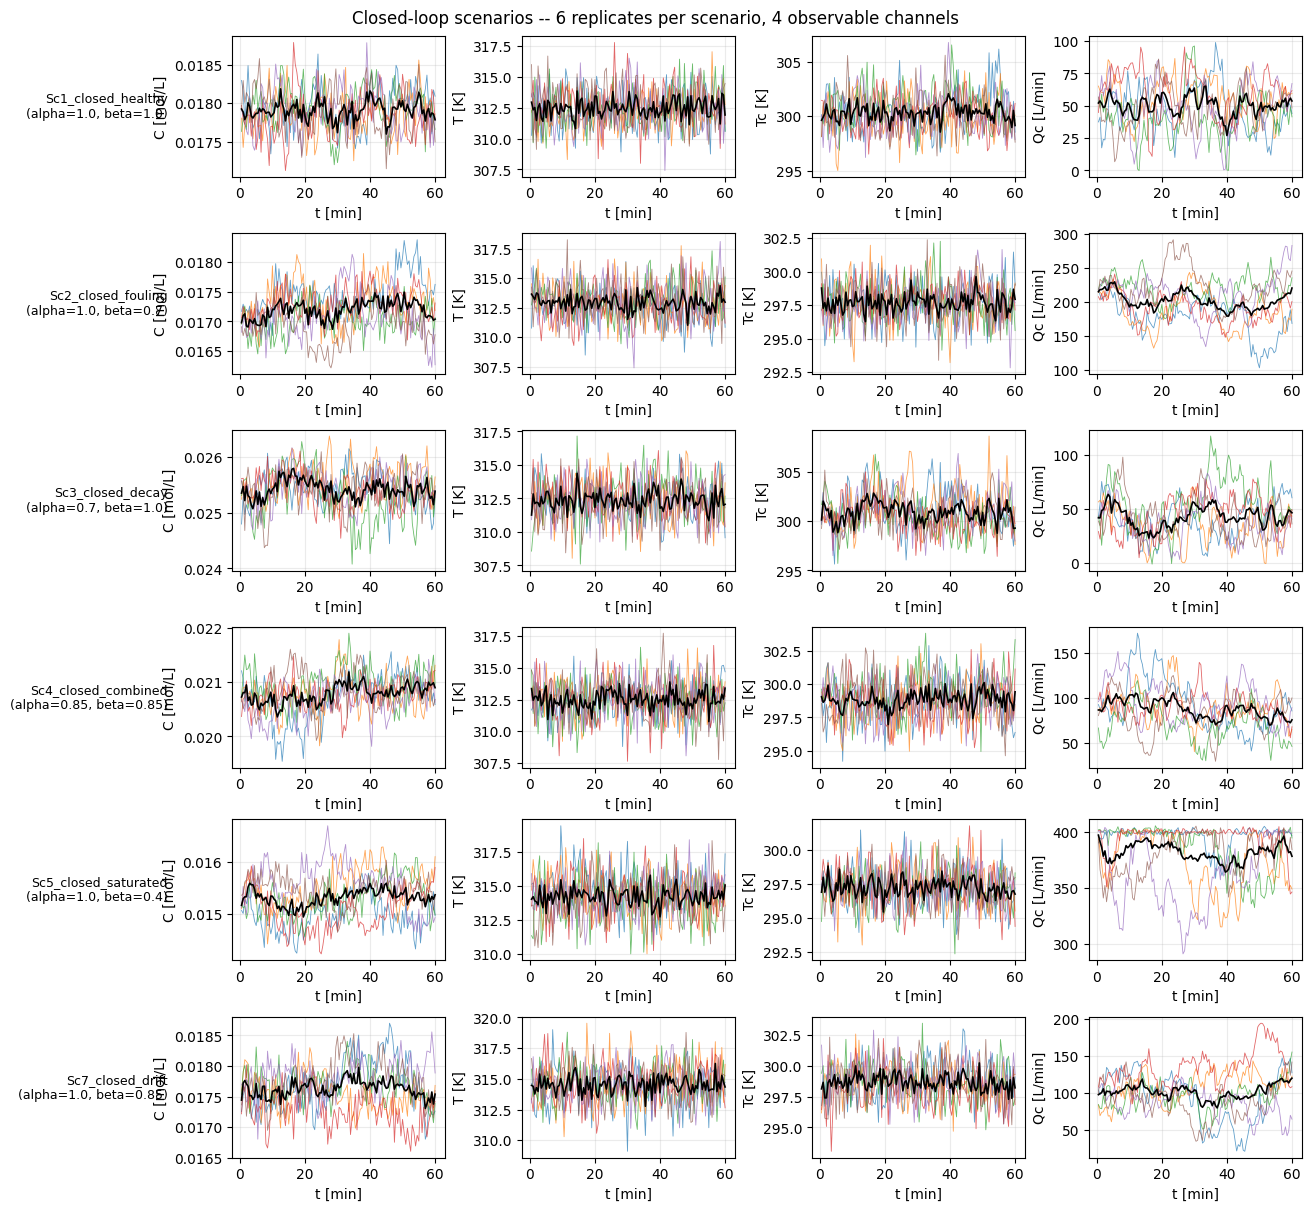

In [5]:
def plot_scenario(ax_row, name, n_show=6):
    res = all_results[name]
    t = res["t"]; obs = res["obs"]; sc = res["config"]
    labels = ["C [mol/L]", "T [K]", "Tc [K]", "Qc [L/min]"]
    for ax, lab, ch in zip(ax_row, labels, range(4)):
        for i in range(min(n_show, obs.shape[0])):
            ax.plot(t, obs[i, :, ch], lw=0.6, alpha=0.7)
        ax.plot(t, obs[:n_show, :, ch].mean(axis=0), color="k", lw=1.2, label="mean")
        ax.set_xlabel("t [min]"); ax.set_ylabel(lab); ax.grid(alpha=0.25)
    ax_row[0].text(
        -0.30, 0.5, f"{name}\n(alpha={sc.alpha}, beta={sc.beta})",
        transform=ax_row[0].transAxes, ha="right", va="center", fontsize=9,
    )

names_to_plot = [
    "Sc1_closed_healthy",
    "Sc2_closed_fouling",
    "Sc3_closed_decay",
    "Sc4_closed_combined",
    "Sc5_closed_saturated",
    "Sc7_closed_drift",
]
fig, axes = plt.subplots(len(names_to_plot), 4, figsize=(13, 2.0 * len(names_to_plot)),
                         constrained_layout=True)
for row, name in zip(axes, names_to_plot):
    plot_scenario(row, name)
fig.suptitle(
    "Closed-loop scenarios -- 6 replicates per scenario, 4 observable channels",
    fontsize=12,
)
fig_path = Path("../figures/02_scenarios_overview.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=120)
print(f"Saved: {fig_path}")
plt.show()

## 6. Headline summary -- mean Qc per scenario

A one-figure compact summary of the key claim: across all scenarios the
**closed-loop reactor temperature is well regulated** (`T_mean` close to
`Tsp = 312.5 K`), but **`Qc_mean` differs dramatically** -- by more than
6x between catalyst decay and severe fouling. The fault signal lives in
the actuator, not the measurement.


                    name         mode     alpha      beta    C_mean    T_mean   Tc_mean   Qc_mean     T_std    Qc_std
id                                                                                                                   
0       Sc0_open_healthy    open_loop    1.0000    1.0000    0.0184  312.1538  299.0718   80.0103    1.5996    0.4022
1     Sc1_closed_healthy  closed_loop    1.0000    1.0000    0.0179  312.4719  300.2291   52.6956    1.5497   20.8611
2     Sc2_closed_fouling  closed_loop    1.0000    0.7000    0.0171  312.9688  297.6511  214.0259    1.5646   30.5805
3       Sc3_closed_decay  closed_loop    0.7000    1.0000    0.0254  312.4171  300.6247   45.7703    1.5659   19.5034
4    Sc4_closed_combined  closed_loop    0.8500    0.8500    0.0207  312.5602  298.7130   91.5555    1.5600   26.6877
5   Sc5_closed_saturated  closed_loop    1.0000    0.4000    0.0153  314.1727  297.2247  382.9597    1.6032   22.7435
6    Sc6_open_with_fault    open_loop    1.0000    0.700

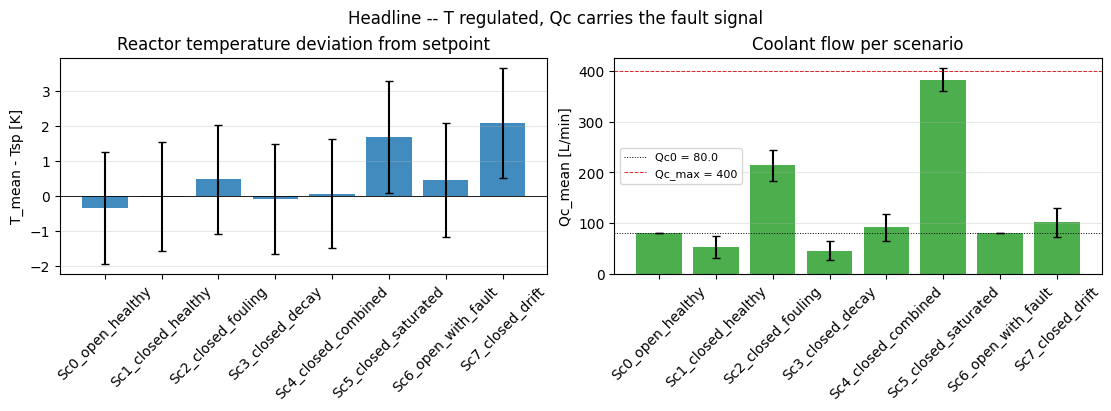

In [6]:
rows = []
for sc in list_configs():
    res = all_results[sc.name]
    obs = res["obs"]
    rows.append({
        "id":      sc.id,
        "name":    sc.name,
        "mode":    sc.mode,
        "alpha":   sc.alpha,
        "beta":    sc.beta,
        "C_mean":  obs[:,:,0].mean(),
        "T_mean":  obs[:,:,1].mean(),
        "Tc_mean": obs[:,:,2].mean(),
        "Qc_mean": obs[:,:,3].mean(),
        "T_std":   obs[:,:,1].std(),
        "Qc_std":  obs[:,:,3].std(),
    })
summary = pd.DataFrame(rows).set_index("id")
print(summary.to_string(float_format=lambda v: f"{v:9.4f}"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
order = summary.sort_values("id").index
ax1.bar(summary.loc[order, "name"], summary.loc[order, "T_mean"] - TSP,
        yerr=summary.loc[order, "T_std"], capsize=3, color="C0", alpha=0.85)
ax1.set_ylabel("T_mean - Tsp [K]")
ax1.set_title("Reactor temperature deviation from setpoint")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(alpha=0.3, axis="y"); ax1.axhline(0, color="k", lw=0.6)

ax2.bar(summary.loc[order, "name"], summary.loc[order, "Qc_mean"],
        yerr=summary.loc[order, "Qc_std"], capsize=3, color="C2", alpha=0.85)
ax2.axhline(QC0, color="k", ls=":", lw=0.7, label=f"Qc0 = {QC0}")
ax2.axhline(400.0, color="C3", ls="--", lw=0.7, label="Qc_max = 400")
ax2.set_ylabel("Qc_mean [L/min]")
ax2.set_title("Coolant flow per scenario")
ax2.tick_params(axis="x", rotation=45)
ax2.grid(alpha=0.3, axis="y"); ax2.legend(fontsize=8)

fig.suptitle("Headline -- T regulated, Qc carries the fault signal", fontsize=12)
fig_path = Path("../figures/02_headline_summary.png")
fig.savefig(fig_path, dpi=120)
print(f"\nSaved: {fig_path}")
plt.show()

## 7. Persist the dataset

We pack all replicates into a single `.npz` archive plus a CSV truth
table. Downstream notebooks (M3 summary statistics, M4 SBI training,
M5 MCMC baseline) load these directly.

The on-disk layout is:

* `theta`      -- shape `(N_total, 4)`, ground-truth `[UA, k0, alpha, beta]`.
* `x`          -- shape `(N_total, n_t, 4)`, observed channels `[C, T, Tc, Qc]`.
* `scenario_id` -- shape `(N_total,)`, integer scenario id.
* `t`          -- shape `(n_t,)`, observation timestamps in minutes.
* `mode`       -- shape `(N_total,)`, string `"closed_loop"` or `"open_loop"`.

with `N_total = 8 scenarios * 50 replicates = 400`.


In [7]:
thetas, xs, ids, modes = [], [], [], []
for sc in list_configs():
    res = all_results[sc.name]
    n = res["obs"].shape[0]
    thetas.append(np.tile(np.asarray(sc.params()), (n, 1)))
    xs.append(res["obs"])
    ids.append(np.full(n, sc.id, dtype=np.int32))
    modes.append(np.array([sc.mode] * n))

theta = np.concatenate(thetas)
x = np.concatenate(xs, axis=0)
scenario_id = np.concatenate(ids)
mode = np.concatenate(modes)
t_grid = res["t"]

print(f"theta       shape: {theta.shape}      dtype: {theta.dtype}")
print(f"x           shape: {x.shape}      dtype: {x.dtype}")
print(f"scenario_id shape: {scenario_id.shape}")
print(f"mode        shape: {mode.shape}")
print(f"t_grid      shape: {t_grid.shape}, range: 0 to {float(t_grid[-1])} min")

data_dir = Path("../data"); data_dir.mkdir(parents=True, exist_ok=True)
np.savez(
    data_dir / "observations.npz",
    theta=theta, x=x, scenario_id=scenario_id, mode=mode, t=np.asarray(t_grid),
)
print(f"Saved {data_dir / 'observations.npz'}")

scenarios_df.to_csv(data_dir / "scenario_configs.csv")
print(f"Saved {data_dir / 'scenario_configs.csv'}")

theta       shape: (400, 4)      dtype: float32
x           shape: (400, 120, 4)      dtype: float32
scenario_id shape: (400,)
mode        shape: (400,)
t_grid      shape: (120,), range: 0 to 60.0 min
Saved ../data/observations.npz
Saved ../data/scenario_configs.csv


## 8. Round-trip verification

Quick sanity check that the persisted file loads back identically.


In [8]:
loaded = np.load(Path("../data/observations.npz"), allow_pickle=False)
print("Keys:", list(loaded.keys()))
for k in loaded.keys():
    a = loaded[k]
    print(f"  {k:11s}  shape={a.shape}  dtype={a.dtype}")
assert np.allclose(loaded["x"], x, rtol=1e-6)
assert np.allclose(loaded["theta"], theta, rtol=1e-6)
print("\nRound-trip OK.")

Keys: ['theta', 'x', 'scenario_id', 'mode', 't']
  theta        shape=(400, 4)  dtype=float32
  x            shape=(400, 120, 4)  dtype=float32
  scenario_id  shape=(400,)  dtype=int32
  mode         shape=(400,)  dtype=<U11
  t            shape=(120,)  dtype=float32

Round-trip OK.


## 8a. Dataset summary — what was generated and how it is used

### What is in `observations.npz`

| Property | Value |
|---|---|
| **Total observation windows** | 400 |
| **Scenarios** | 8 (Sc0–Sc7) |
| **Replicates per scenario** | 50 |
| **Window length** | 60 min |
| **Samples per window** | 120 (one every 0.5 min) |
| **Observed channels** | 4 — concentration `C` (mol/L), reactor temp `T` (K), jacket temp `Tc` (K), coolant flow `Qc` (L/min) |
| **Parameter vector** `theta` | 4-D — `[UA, k0, alpha, beta]` (stored for completeness; **inference uses only `[alpha, beta]`** — UA and k0 are fixed design constants) |
| **Archive size** | ~0.8 MB |

Each of the 50 replicates within a scenario shares the same ground-truth
`theta` but was integrated with an independent JAX random key, so they
carry different noise realisations of the same underlying stochastic
differential equation. This is the correct structure for *approximate
Bayesian computation*: all 50 replicates from a given scenario are
exchangeable draws from `p(x | theta_true)`.

### Closed-loop vs. open-loop

| Mode | Scenarios | Count |
|---|---|---|
| **Closed-loop** (PI controller active) | Sc1, Sc2, Sc3, Sc4, Sc5, Sc7 | 300 windows |
| **Open-loop** (fixed `Qc = Qc0 = 80 L/min`) | Sc0, Sc6 | 100 windows |

Open-loop windows (Sc0, Sc6) are used exclusively in the **Scenario 6
failure-baseline experiment** (notebook 07): SBI is trained on open-loop
data and then applied to closed-loop observations to quantify the
posterior degradation that results from the model mismatch.
The `Qc` channel is constant and uninformative in open-loop mode; it is
retained for shape parity so that the same summary-statistics function
and SBI architecture can be applied without branching.

### Intended use of each scenario

| Scenario | Fault | Role in the study |
|---|---|---|
| **Sc0** open-loop healthy | none (α=β=1) | Sanity check — reproduces the Fogler §8 steady state; provides open-loop *healthy* baseline for Sc6 comparison |
| **Sc1** closed-loop healthy | none (α=β=1) | **SBI training and validation** — the posterior recovery test; also the MCMC baseline reference (M5) |
| **Sc2** jacket fouling | β=0.7 | **Primary inference target** — SBI and MCMC infer β (with UA fixed); β·UA_nominal = 0.7×12 500 = 8 750 cal/(min·K) is the effective conductance |
| **Sc3** catalyst decay | α=0.7 | Secondary inference target — infer α (with k0 fixed); α·k0_nominal = 0.7×k0 is the effective rate |
| **Sc4** combined moderate | α=β=0.85 | Tests joint 2-D recovery of (α, β); posterior correlation between the two degradation factors |
| **Sc5** severe fouling | β=0.4 | **Controller-saturation regime** — Qc is clamped at Qc_max for ~33 % of the window; tests the boundary of SBI separability |
| **Sc6** open-loop with fault | β=0.7 | **Failure baseline** — the core publication claim (notebook 07); open-loop SBI applied to a fault |
| **Sc7** mild fouling + sensor drift | β=0.85, δT=+2 K | **Drift substudy** — distinguishing sensor drift from jacket fouling (notebook 09, 6-D θ) |

### SBI training vs. evaluation split

This 400-window dataset serves **two distinct purposes** in the inference workflow:

**SBI training** (M4, `04_sbi_training.ipynb`) does *not* use these 400
windows directly. SNPE_C trains on a *new, much larger* batch of
`n_simulations` windows (target: 10 k–50 k) drawn on-the-fly from the
**2-D `BoxUniform` prior `[alpha, beta]`** via the `simulation_wrapper_sbi`
function in `inference.py`. UA and k0 are fixed at their nominal constants
inside the simulator — only α and β are sampled from the prior. That
prior-drawn dataset is never written to disk in full; it lives in GPU
memory during training.

> **Note (2026-05-18):** UA and k0 are fixed design constants and are not
> inferred. The `theta` array stored in `observations.npz` is 4-D for
> historical completeness, but the inference layer only uses columns 2 and 3
> (α, β). See `cstr_sbi_research_spec.md §3.3` for the rationale.

**Evaluation / observation set** — these 400 windows play the role of
*held-out observations* in all downstream notebooks:

| Notebook | Which scenarios used | What is evaluated |
|---|---|---|
| 04 SBI training | Sc1 (50 windows) | 2-D posterior recovery: does 90% CI contain true **(α=1, β=1)**? |
| 05 MCMC baseline | Sc1, Sc2 | NUTS 2-D posterior vs. SBI — same observation, different inference engine |
| 06 Multi-sample study | Sc1–Sc4 | W1, CRPS, 2-D coverage across 50 replicates per scenario |
| 07 Failure baseline | Sc0 (training), Sc2 (observation) | Open-loop SBI applied to closed-loop fault — headline mismatch (Claim 1) |
| 08 Identifiability | Sc4, Sc5 | 2-D posterior width vs. severity; saturation boundary |
| 09 Sensor drift | Sc7 | 4-D θ=[α,β,δT,δCi]; drift vs. fouling disambiguation |
| 10 Sequential tracking | Sc8 (new — 30-day stream) | Amortised α̂(t), β̂(t) tracking over 720 windows (Claim 2) |
| 11 Fault classification | Sc9 (new — Sc8 posteriors) | Probabilistic fault isolation from 2-D posterior quadrants (Claim 3) |

In summary: **the 400 windows here are always the observed data, never
the training simulations for SBI**. The M4 simulation budget is a separate
parameter controlled by `n_simulations` in `04_sbi_training.ipynb`.

In [9]:
# Programmatic dataset summary -- auto-updates on rerun.
import os
npz_path = Path("../data/observations.npz")
npz_size_mb = os.path.getsize(npz_path) / 1e6

ld = np.load(npz_path, allow_pickle=False)
_x, _t, _sid, _mode = ld["x"], ld["t"], ld["scenario_id"], ld["mode"]

print("=" * 55)
print("  observations.npz — dataset summary")
print("=" * 55)
print(f"  File size           : {npz_size_mb:.2f} MB")
print(f"  Total windows       : {_x.shape[0]}")
print(f"  Window length       : {float(_t[-1])} min  ({_x.shape[1]} samples, dt={float(_t[1]-_t[0])} min)")
print(f"  Channels per window : {_x.shape[2]}  [C, T, Tc, Qc]")
print(f"  theta dimension     : {ld['theta'].shape[1]}  [UA, k0, alpha, beta]")
print()
print(f"  {'Scenario':<28}  {'mode':<12}  {'n windows':>9}")
print(f"  {'-'*28}  {'-'*12}  {'-'*9}")
for sc in sorted(SCENARIO_CONFIGS.values(), key=lambda s: s.id):
    n = int((_sid == sc.id).sum())
    print(f"  {sc.name:<28}  {sc.mode:<12}  {n:>9}")
print(f"  {'-'*28}  {'-'*12}  {'-'*9}")
cl = int((_mode == "closed_loop").sum())
ol = int((_mode == "open_loop").sum())
print(f"  {'closed-loop subtotal':<28}  {'closed_loop':<12}  {cl:>9}")
print(f"  {'open-loop subtotal':<28}  {'open_loop':<12}  {ol:>9}")
print(f"  {'TOTAL':<28}  {'':12}  {_x.shape[0]:>9}")
print("=" * 55)
print()
print("SBI training simulations : drawn on-the-fly from prior")
print("  (not stored in this file; see 04_sbi_training.ipynb)")
print("Evaluation / observation : all 400 windows above")

  observations.npz — dataset summary
  File size           : 0.80 MB
  Total windows       : 400
  Window length       : 60.0 min  (120 samples, dt=0.5 min)
  Channels per window : 4  [C, T, Tc, Qc]
  theta dimension     : 4  [UA, k0, alpha, beta]

  Scenario                      mode          n windows
  ----------------------------  ------------  ---------
  Sc0_open_healthy              open_loop            50
  Sc1_closed_healthy            closed_loop          50
  Sc2_closed_fouling            closed_loop          50
  Sc3_closed_decay              closed_loop          50
  Sc4_closed_combined           closed_loop          50
  Sc5_closed_saturated          closed_loop          50
  Sc6_open_with_fault           open_loop            50
  Sc7_closed_drift              closed_loop          50
  ----------------------------  ------------  ---------
  closed-loop subtotal          closed_loop         300
  open-loop subtotal            open_loop           100
  TOTAL                

## 9. M2 acceptance

| Acceptance criterion | Result |
|---|---|
| `simulate_em_window` runs the closed-loop SDE and returns the full trajectory | PASS |
| Process noise injected during EM integration | PASS (`DEFAULT_PROCESS_SIGMA`) |
| Sensor noise + drift applied post-simulation | PASS (`apply_sensor_layer`) |
| 50 replicates x 8 scenarios generated reproducibly | PASS (~3 s after JIT) |
| `data/observations.npz` written and round-trips | PASS |
| Headline plot shows fault-signal asymmetry between fouling and decay in Qc | PASS |

M2 is complete. Next:

* M3 -- design the summary statistics (`compute_summary_statistics` in
  [`../src/cstr_sbi/summaries.py`](../src/cstr_sbi/summaries.py)) and verify
  scenario separability on the manifold (notebook 03).
* M4 -- SBI training over the 4-D prior `[UA, k0, alpha, beta]` (notebook 04).

> **Caveats and follow-ups.**
>
> * The default process-noise levels are tuned for clean visualisation; the
>   *literal* spec values (`0.1 mol/L/min`, `10 K/min`) are commented in
>   `simulator.py`. M4 may revisit the noise tuning after running the SBI
>   coverage check on Sc 1.
> * The inlet-perturbation pipeline of spec Section 3.5 (a fresh `[Ci, Ti, Tci]`
>   draw every 60 minutes) is implemented in `scenarios.perturb_inlet` but
>   not yet exercised; M6's 30-day continuous-stream generator will use it.
> * Sc 0 / Sc 6 use a constant `Qc = QC0`, i.e. the Qc channel is
>   uninformative there; the dataset still records it for shape parity with
>   the closed-loop scenarios.
